In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager

options = Options()

options.add_argument("--start-maximized")
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

titles = []
ratings = []
comments = []

for i in range(1, 14):

    if i == 1:
        url = "https://www.mouthshut.com/product-reviews/sennheiser-cx-180-street-ii-in-ear-earphones-reviews-925864174"
    else:
        url = f"https://www.mouthshut.com/product-reviews/sennheiser-cx-180-street-ii-in-ear-earphones-reviews-925864174-page-{i}"

    print(f"Scraping Page {i}")

    driver.get(url)

    WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.CLASS_NAME, "review-article"))
    )

    reviews = driver.find_elements(By.CLASS_NAME, "review-article")

    for review in reviews:
        try:
            title = review.find_element(By.XPATH, ".//a[contains(@id,'lnkTitle')]").text
        except:
            title = None

        stars = review.find_elements(By.CLASS_NAME, "rated-star")
        rating = len(stars)

        try:
            comment = review.find_element(By.CLASS_NAME, "reviewdata").text
        except:
            comment = None

        titles.append(title)
        ratings.append(rating)
        comments.append(comment)

driver.quit()

df = pd.DataFrame({
    "Title": titles,
    "Rating": ratings,
    "Comment": comments
})

df.to_csv("sennheiser_reviews.csv", index=False)
print("Scraping completed successfully!")

Scraping Page 1
Scraping Page 2
Scraping Page 3
Scraping Page 4
Scraping Page 5
Scraping Page 6
Scraping Page 7
Scraping Page 8
Scraping Page 9
Scraping Page 10
Scraping Page 11
Scraping Page 12
Scraping Page 13
Scraping completed successfully!


In [15]:
import pandas as pd

df = pd.read_csv("sennheiser_reviews_2.csv")

print(df.head())
print(df.info())

                                Title  Rating  \
0        Great earphone at best price       5   
1    Best budget headset for everyone       5   
2  Enjoy music with Sennheiser cx 180       3   
3                                 NaN       0   
4        The best earphones under 1K.       4   

                                             Comment  
0  I just love this earphone. I was using this ea...  
1  I have purchased this almost 10 to 15 times fo...  
2  I am using CX 180 from last one year it has be...  
3                                                NaN  
4  I have been using this earphone for 3 months.I...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Title    259 non-null    object
 1   Rating   260 non-null    int64 
 2   Comment  259 non-null    object
dtypes: int64(1), object(2)
memory usage: 6.2+ KB
None


In [16]:
df.dropna(subset=["Comment"], inplace=True)
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [17]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)["compound"]
    
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Comment"].apply(get_sentiment)

print(df["Sentiment"].value_counts())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Student\AppData\Roaming\nltk_data...


Sentiment
Positive    229
Negative     28
Neutral       2
Name: count, dtype: int64


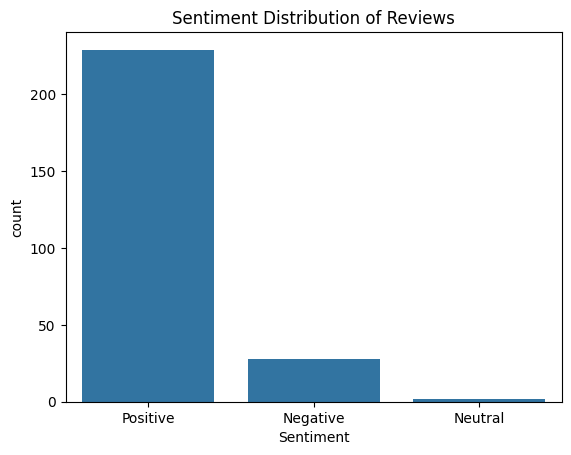

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Distribution of Reviews")
plt.show()

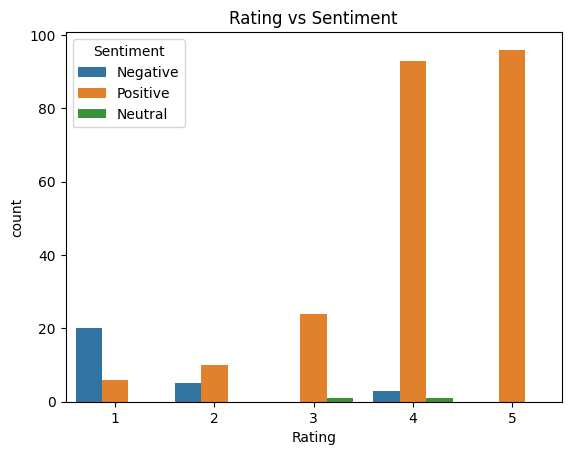

In [19]:
sns.countplot(x="Rating", hue="Sentiment", data=df)
plt.title("Rating vs Sentiment")
plt.show()

In [20]:
print("Average Rating:", df["Rating"].mean())

Average Rating: 3.857142857142857
